## visualizing MRtrix3 derived tractometry from track scalar files (.tsf)

In [1]:
import os
from os import mkdir, path
import nibabel as nib
from nibabel.streamlines import TckFile
import pooch

import yabplot as yab

### using XTRACT standard tracks and JHU-ICBM DTI FA map
probabilistic tractography derived from the Human Connectome Project.
* **key:** `'xtract_small'` (subset) or `'hcp1065'` (full)
* **reference:** [Warrington et al., 2020](https://doi.org/10.1126/sciadv.aba8245)

FA map is derived from [JHU-ICBM-FA-2mm](https://neurovault.org/collections/264/).
* **key:** `'JHU-ICBM-FA-2mm'`
* **reference:** [Mori et al., 2008](https://doi.org/10.1016/j.neuroimage.2007.12.035)


In [2]:
trks=yab.get_atlas_regions('xtract_small', 'tracts')
fa_path = pooch.retrieve("https://neurovault.org/media/images/264/JHU-ICBM-FA-2mm.nii.gz",
               known_hash="md5:37a29959c5e3c1db9acc9064b6cad87f")

Unzipping contents of '/Volumes/Users/jdenecke/Library/Caches/yabplot/tracts-xtract_small.zip' to '/Volumes/Users/jdenecke/Library/Caches/yabplot/tracts-xtract_small'


### transform .trk to .tck files for use in MRtrix3

MRtrix3 cannot handle .trk files. therefore, we need to transform them to MRtrix3 native .tck files.

this requires adding header information, utilize the JHU-ICBM-FA-2mm image for that.

In [3]:

xtract_small_path = yab.data._resolve_resource_path('xtract_small', 'tracts')
xtract_small_trks = yab.data._find_tract_files(xtract_small_path)
xtract_small_tck_path = path.join(yab.data.CACHE_DIR, 'xtract_small_tck')
if not path.isdir(xtract_small_tck_path): mkdir(xtract_small_tck_path)

for trk, trk_path in xtract_small_trks.items():
    out_tck_path = path.join(xtract_small_tck_path, trk + '.tck')
    #save trk as tck
    if not path.isfile(out_tck_path):
        # 1) read anatomy for affine and dims
        img = nib.load(fa_path)

        # 2) load trk tractogram
        trk_file = nib.streamlines.load(trk_path)
        tractogram = getattr(trk_file, "tractogram", trk_file)

        # 3) build tck header
        tck_header = {
            "voxel_to_rasmm": img.affine,
            "dimensions": tuple(img.shape[:3])
        }

        # 4) create tck file and save
        tck = TckFile(tractogram, header=tck_header)
        tck.save(out_tck_path)

### create FA based .tsf files (i.e. tractometry)

this part requires MRtrix3 installed to call tcksample.

tcksample takes an input tck, a map to sample (e.g. DTI-FA), and outputs a track scalar file (.tsf) with interpolated FA values for each vertex of each streamline of that tck. in order for tcksample to produce a .tsf file, the filename must end with .tsf. otherwise, tcksample will produce a .csv file.

In [4]:

xtract_small_tcks = yab.data._find_tract_files(xtract_small_tck_path)

xtract_small_tsf_path = path.join(yab.data.CACHE_DIR, 'xtract_small_tsf')
if not path.isdir(xtract_small_tsf_path): mkdir(xtract_small_tsf_path)

tsfPathDict = {}
for tck, tck_path in xtract_small_tcks.items():
    out_tsf_path = path.join(xtract_small_tsf_path, tck + '.tsf')
    if not path.isfile(out_tsf_path):
        os.system(f"tcksample {tck_path} {fa_path} {out_tsf_path}")
    tsfPathDict[tck] = out_tsf_path


tcksample: [100%] uncompressing image "/Volumes/Users/jdenecke/Library/Caches/pooch/8a410e4f83e0f8923701396cad15887e-JHU-ICBM-FA-2mm.nii.gz"[0K
tcksample: [100%] Sampling values underlying streamlines[0K
tcksample: [100%] uncompressing image "/Volumes/Users/jdenecke/Library/Caches/pooch/8a410e4f83e0f8923701396cad15887e-JHU-ICBM-FA-2mm.nii.gz"[0K
tcksample: [100%] Sampling values underlying streamlines[0K
tcksample: [100%] uncompressing image "/Volumes/Users/jdenecke/Library/Caches/pooch/8a410e4f83e0f8923701396cad15887e-JHU-ICBM-FA-2mm.nii.gz"[0K
tcksample: [100%] Sampling values underlying streamlines[0K
tcksample: [100%] uncompressing image "/Volumes/Users/jdenecke/Library/Caches/pooch/8a410e4f83e0f8923701396cad15887e-JHU-ICBM-FA-2mm.nii.gz"[0K
tcksample: [100%] Sampling values underlying streamlines[0K
tcksample: [100%] uncompressing image "/Volumes/Users/jdenecke/Library/Caches/pooch/8a410e4f83e0f8923701396cad15887e-JHU-ICBM-FA-2mm.nii.gz"[0K
tcksample: [100%] Sampling values underl

### plotting tractometry

calling plot_tracts with our .tck directory (can also be replaced with atlas='xtract_small') and providing a dictionary with tract names as keys and the .tsf file path as value. supports dicts, arrays, lists. however, arrays and lists must strictly match the sorted list of tracts in the atlas.

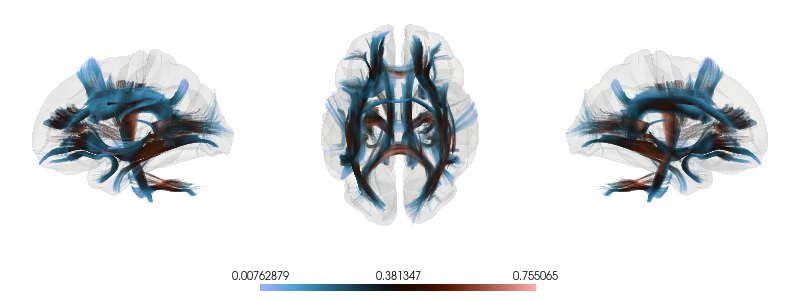

In [16]:
    yab.plot_tracts(custom_atlas_path=xtract_small_tck_path, data=tsfPathDict, orientation_coloring=False, views=['left_lateral', 'superior', 'left_medial'], figsize=(800, 300),  alpha=0.05, cmap="berlin")